# 18 — Analisi per cluster delle lunghezze dei riassunti

Questo notebook **non genera nulla**: legge i file di metriche già salvati in `results/metrics/`
(colonna `parole_generate`) e li incrocia con `data/tab/complete.tab` per rispondere a una domanda
che le medie aggregate per metodo (55 parole per `bart` → 477 per `lda`, viste nel notebook 05) non
coprono — **dentro un singolo cluster Multi-News**, quanto sono diversi fra loro i riassunti dei
18 metodi, e quanto si avvicinano al riassunto di riferimento di quel cluster?

Origine: richiesta del relatore di verificare le lunghezze e, in caso di disomogeneità
significative, contenere la distribuzione dentro un intervallo comune — dettagli e decisioni in
[issue #15](../../../issues/15) (sostituisce la #14, che aveva individuato il problema ma solo per
`lda`/notebook 15-17).

Quattro cose vengono calcolate, tutte a partire da file già committati:

1. **Dispersione dentro ciascun cluster** — spread (max − min), rapporto max/min, coefficiente di
   variazione, spread rapportato alla lunghezza del riferimento.
2. **Per metodo** — distribuzione di `lunghezza / riferimento`, quota di cluster dentro la banda
   obiettivo, e quanto la lunghezza generata segue quella del riferimento (e il numero di
   articoli del cluster) — nella maggior parte dei metodi, non lo fa.
3. **`T(n_articoli)`** — la mediana della lunghezza del riferimento per numero di articoli del
   cluster, tarata sulla split **train**: il primo candidato naturale a budget per-cluster.
4. **Confronto dei predittori del budget** — quanto bene la lunghezza del riferimento si lascia
   prevedere dal solo input (numero di articoli, lunghezza della sorgente, entrambi), contro un
   budget costante e contro il riferimento stesso. È la sezione che decide *quale* budget usare
   per il contenimento, e la risposta non è quella che ci si aspettava.

Le lunghezze sono conteggi di parole (`str.split()`, tokenizer-free — la convenzione usata in
tutto il repository), già presenti in `parole_generate` in ogni CSV per-esempio: nessun riassunto
viene rigenerato né alcuna metrica ricalcolata qui.


In [1]:
# --- Configurazione ---------------------------------------------------------
import json
import os
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
BUDGET_PATH = BASE / 'scripts' / 'budget_lunghezza.json'

# Ambito da analizzare: 'test' finche' il contenimento non esiste, poi anche
# l'ambito rigenerato per il confronto prima/dopo. Stessa variabile d'ambiente
# usata dai notebook di generazione, cosi' un driver puo' selezionarlo dall'esterno.
SCOPE = os.environ.get('SUMM_SCOPE', 'test')
SPLIT_RIFERIMENTI = 'test'   # split di complete.tab da cui leggere i riferimenti

# I cluster con almeno questo numero di articoli condividono l'ultimo bucket di
# T(n_articoli): oltre, il campione per bucket diventa troppo piccolo per una
# mediana stabile (22 cluster a 8+ sulla sola split test, 304 su train).
BUCKET_MASSIMO = 8

# Banda obiettivo attorno al budget. Il bordo inferiore e' quanto il solo
# troncamento non potra' mai raggiungere per i metodi piu' corti; quello
# superiore e' il tetto che applichera' il contenimento delle lunghezze.
BANDA = (0.80, 1.25)
PERCENTILI = (10, 25, 50, 75, 90)

# Stessa palette del notebook 05 (18 colori scelti massimizzando la distanza
# minima OKLab, con penalita' protanopia/deutanopia): l'identita' visiva di un
# metodo resta la stessa in tutto il benchmark.
COLORI = {'firstk_psr': '#5f6b7a', 'firstk_nltk': '#c2410c',
          'centroid_mmr': '#0d9488', 'centroid_mmr_bert': '#4338ca',
          'textrank': '#2a78d6', 'lexrank': '#1baf7a',
          'bart': '#eda100', 'pegasus': '#008300', 'primera': '#8250df',
          'qwen': '#d6336c', 'gemma': '#15aabf', 'mistral': '#846358',
          'gpt5mini': '#e8590c',
          'lsa': '#900090', 'lsa_steinberger': '#b840b0',
          'sbert_kmeans': '#8088f8', 'sbert_agglom': '#803860',
          'lda': '#a01018'}
INK, INK2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'

print(f"Ambito analizzato: '{SCOPE}' (split riferimenti: '{SPLIT_RIFERIMENTI}')")


Ambito analizzato: 'test' (split riferimenti: 'test')


## Caricamento

Le lunghezze generate vengono dai CSV per-esempio già scritti da `summ_utils.valuta_e_salva`
(colonna `parole_generate`); i file G-Eval non hanno quella colonna e restano esclusi dal solo
fatto di non corrispondere al pattern. Riferimento, numero di articoli e lunghezza della sorgente
per cluster vengono da un'unica scansione in streaming di `complete.tab` (~1 minuto), sulla split
analizzata **e** sulla split train: la seconda serve a tarare i candidati a budget senza usare le
etichette su cui poi si misura.


In [2]:
def carica_lunghezze(metrics_dir, scope):
    """{metodo: {row_id: parole}} dai CSV per-esempio committati di `scope`."""
    suffisso = f'_{scope}_per_example.csv'
    dati = {}
    for path in sorted(Path(metrics_dir).glob(f'*{suffisso}')):
        metodo = path.name[:-len(suffisso)]
        per_riga = {}
        with open(path, encoding='utf-8', newline='') as f:
            for riga in pd.read_csv(f, usecols=['row_id', 'parole_generate']).itertuples():
                per_riga[int(riga.row_id)] = int(riga.parole_generate)
        if per_riga:
            dati[metodo] = per_riga
    return dati


def scansiona_complete_tab(path, splits):
    """Un'unica passata in streaming.

    -> {split: [(row_id, n_articoli, parole_riferimento, parole_sorgente)]}

    Il numero di articoli si conta sul documento GREZZO (separatore '|||||'): dopo
    `prepara_documento` il separatore e' diventato un newline, indistinguibile dai
    newline interni a un articolo. La sorgente e' contata con il separatore tolto.
    """
    voluti = set(splits)
    out = {s: [] for s in splits}
    for es in su.itera_complete_tab(path):
        if es['split'] not in voluti:
            continue
        doc = es['document']
        n_articoli = doc.count(su.SEPARATORE_ARTICOLI) + 1
        parole_rif = len(su.pulisci_riferimento(es['summary']).split())
        parole_src = len(doc.replace(su.SEPARATORE_ARTICOLI, ' ').split())
        out[es['split']].append((es['row_id'], n_articoli, parole_rif, parole_src))
    return out


lunghezze = carica_lunghezze(P['metrics_dir'], SCOPE)
print(f"Metodi trovati per l'ambito '{SCOPE}': {len(lunghezze)} -> {sorted(lunghezze)}")

split_da_leggere = [SPLIT_RIFERIMENTI] + (['train'] if SPLIT_RIFERIMENTI != 'train' else [])
print(f"Scansione di {P['complete_tab'].name} (split: {', '.join(split_da_leggere)})...")
righe = scansiona_complete_tab(P['complete_tab'], split_da_leggere)
print(', '.join(f"{len(v)} cluster (split '{s}')" for s, v in righe.items()))


Metodi trovati per l'ambito 'test': 18 -> ['bart', 'centroid_mmr', 'centroid_mmr_bert', 'firstk_nltk', 'firstk_psr', 'gemma', 'gpt5mini', 'lda', 'lexrank', 'lsa', 'lsa_steinberger', 'mistral', 'pegasus', 'primera', 'qwen', 'sbert_agglom', 'sbert_kmeans', 'textrank']
Scansione di complete.tab (split: test, train)...


5610 cluster (split 'test'), 44880 cluster (split 'train')


## Il candidato naturale: `T(n_articoli)`

Il riassunto di riferimento non ha una lunghezza costante: cresce con il numero di articoli del
cluster. `T(n_articoli)` — la mediana del riferimento per bucket di articoli — è quindi il primo
candidato che viene in mente come budget di parole per-cluster. **Tarato sulla split train**,
così le etichette della split test non entrano nel budget con cui poi si misura.

Se `scripts/budget_lunghezza.json` esiste già, questa cella lo riusa invece di ricalcolarlo — la
tabella è un **parametro** del benchmark, non un output da rigenerare a ogni esecuzione. Se sia
davvero il budget giusto lo decide la Vista 5, più sotto.


In [3]:
def tabella_budget(righe_train, bucket_massimo=BUCKET_MASSIMO):
    per_bucket = defaultdict(list)
    for _, n_articoli, parole_rif, _ in righe_train:
        per_bucket[min(n_articoli, bucket_massimo)].append(parole_rif)
    tabella = {str(n): int(round(float(np.median(v)))) for n, v in sorted(per_bucket.items())}
    conteggi = {str(n): len(v) for n, v in sorted(per_bucket.items())}
    return tabella, conteggi


if not BUDGET_PATH.exists():
    T, conteggi_T = tabella_budget(righe['train'])
    BUDGET_PATH.write_text(json.dumps({
        'descrizione': 'T(n_articoli): mediana della lunghezza (parole) del riassunto di '
                       'riferimento per numero di articoli del cluster (issue #15).',
        'split_di_taratura': 'train', 'bucket_massimo': BUCKET_MASSIMO, 'banda': list(BANDA),
        'n_cluster_per_bucket': conteggi_T, 'tabella': T,
    }, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Tabella budget scritta: {BUDGET_PATH}')
else:
    contenuto = json.loads(BUDGET_PATH.read_text(encoding='utf-8'))
    T, conteggi_T = contenuto['tabella'], contenuto['n_cluster_per_bucket']
    print(f'Tabella budget riusata da {BUDGET_PATH} (gia\' presente)')

tabella_T = pd.DataFrame({'T (parole)': T, 'n_cluster (train)': conteggi_T})
tabella_T.index.name = 'n_articoli'
display(tabella_T)


Tabella budget riusata da C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\scripts\budget_lunghezza.json (gia' presente)


,T (parole),n_cluster (train)
n_articoli,,
1,164,458
2,194,23703
3,232,12574
4,250,4918
5,270,1845
6,287,707
7,304,371
8,327,304


## Analisi

Ristretta ai `row_id` coperti da **tutti** i metodi trovati per questo ambito (stessa logica di
intersezione del notebook 05).


In [4]:
def distribuzione(valori, cifre=2):
    a = np.asarray(valori, dtype=np.float64)
    d = {f'p{p}': round(float(np.percentile(a, p)), cifre) for p in PERCENTILI}
    d.update(media=round(float(a.mean()), cifre), min=round(float(a.min()), cifre),
             max=round(float(a.max()), cifre), n=int(a.size))
    return d


def pearson(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size < 2 or x.std() == 0 or y.std() == 0:
        return None
    return round(float(np.corrcoef(x, y)[0, 1]), 3)


def budget_riga(n_articoli, tabella=T, bucket_massimo=BUCKET_MASSIMO):
    return tabella[str(min(n_articoli, bucket_massimo))]


riferimento = {row_id: (n_articoli, parole_rif) for row_id, n_articoli, parole_rif, _
              in righe[SPLIT_RIFERIMENTI]}
metodi = sorted(lunghezze)
comuni = sorted(set.intersection(*(set(d) for d in lunghezze.values())) & set(riferimento))
print(f'Cluster in comune fra i {len(metodi)} metodi e il riferimento: {len(comuni)}')

# --- 1. dispersione dentro ciascun cluster ---
spread, rapporto_max_min, cv, spread_rel = [], [], [], []
for row_id in comuni:
    L = np.array([lunghezze[m][row_id] for m in metodi], dtype=np.float64)
    parole_rif = riferimento[row_id][1]
    spread.append(L.max() - L.min())
    rapporto_max_min.append(L.max() / max(L.min(), 1.0))
    cv.append(L.std() / L.mean() if L.mean() else 0.0)
    spread_rel.append((L.max() - L.min()) / max(parole_rif, 1))

dispersione = {'spread_parole': distribuzione(spread, 1),
              'rapporto_max_min': distribuzione(rapporto_max_min, 2),
              'cv': distribuzione(cv, 3),
              'spread_su_riferimento': distribuzione(spread_rel, 2)}

# --- 2. per metodo ---
R = np.array([riferimento[r][1] for r in comuni], dtype=np.float64)   # parole riferimento
A = np.array([riferimento[r][0] for r in comuni], dtype=np.float64)   # numero di articoli
B = np.array([budget_riga(riferimento[r][0]) for r in comuni], dtype=np.float64)

per_metodo = {}
for m in metodi:
    L = np.array([lunghezze[m][r] for r in comuni], dtype=np.float64)
    in_banda = float(((L >= BANDA[0] * B) & (L <= BANDA[1] * B)).mean())
    per_metodo[m] = {
        'parole': distribuzione(L, 1),
        'rapporto_riferimento': distribuzione(L / np.maximum(R, 1), 2),
        'rapporto_budget': distribuzione(L / B, 2),
        'pct_in_banda': round(100 * in_banda, 1),
        'corr_len_riferimento': pearson(L, R),
        'corr_len_n_articoli': pearson(L, A),
    }

print('Analisi completata.')


Cluster in comune fra i 18 metodi e il riferimento: 5437
Analisi completata.


## Vista 1 — Dispersione dentro ciascun cluster

Nel cluster tipico, quanto è diverso il riassunto più lungo dal più corto?


,p10,p25,p50,p75,p90,media,min,max
spread max-min (parole),265.000,329.000,409.000,503.000,609.000,431.700,48.000,7701.000
rapporto max/min,5.590,6.840,8.510,10.580,13.050,9.210,2.020,297.190
CV (std/media),0.345,0.383,0.432,0.488,0.546,0.442,0.177,1.746
spread / lunghezza riferimento,1.230,1.520,1.950,2.530,3.260,2.150,0.280,25.500


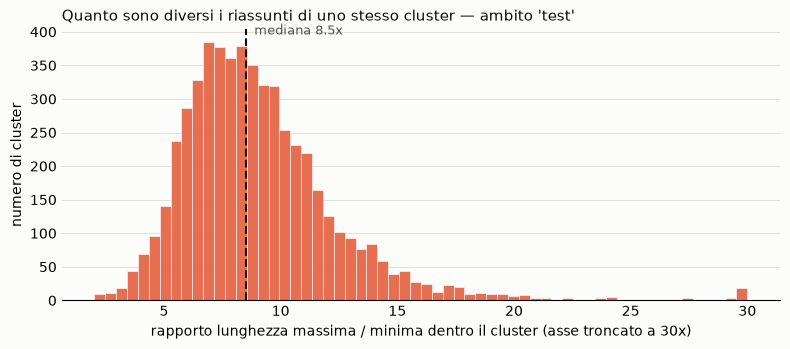

In [5]:
import matplotlib.pyplot as plt

nomi_dispersione = {'spread_parole': 'spread max-min (parole)',
                    'rapporto_max_min': 'rapporto max/min',
                    'cv': 'CV (std/media)',
                    'spread_su_riferimento': 'spread / lunghezza riferimento'}
tabella_dispersione = pd.DataFrame({nomi_dispersione[k]: dispersione[k] for k in dispersione}).T
display(tabella_dispersione[[f'p{p}' for p in PERCENTILI] + ['media', 'min', 'max']])

fig, ax = plt.subplots(figsize=(8, 3.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
rapporto_arr = np.asarray(rapporto_max_min)
ax.hist(np.clip(rapporto_arr, 0, 30), bins=60, color='#e76f51', edgecolor='white', lw=0.4,
       zorder=2)
mediana = float(np.median(rapporto_arr))
ax.axvline(mediana, color=INK, lw=1.5, ls='--', zorder=3)
ax.annotate(f'mediana {mediana:.1f}x', (mediana, ax.get_ylim()[1] if ax.get_ylim()[1] else 1),
           xytext=(6, -4), textcoords='offset points', fontsize=9, color=INK2)
ax.set_xlabel('rapporto lunghezza massima / minima dentro il cluster (asse troncato a 30x)')
ax.set_ylabel('numero di cluster')
ax.set_title(f"Quanto sono diversi i riassunti di uno stesso cluster — ambito '{SCOPE}'",
            color=INK, loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


## Vista 2 — Il bersaglio non è costante

Lunghezza del riassunto di riferimento sull'ambito analizzato, e come cresce col numero di
articoli del cluster (bucket `T(n_articoli)` calcolati sopra, sulla split train). La tendenza è
reale; quanto sia *utile* per prevedere il singolo cluster lo dice la Vista 5.


Lunghezza del riferimento:


,p10,p25,p50,p75,p90,media,min,max,n
parole riferimento,129.0,167.0,217.0,259.0,292.0,215.5,54.0,615.0,5437.0


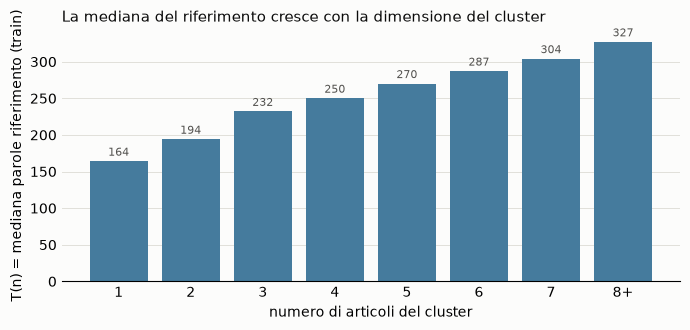

In [6]:
print('Lunghezza del riferimento:')
display(pd.Series(distribuzione(R, 1)).to_frame('parole riferimento').T)

fig, ax = plt.subplots(figsize=(7, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bucket = [int(k) for k in T]
valori_T = [T[str(k)] for k in bucket]
ax.bar([str(k) if k < BUCKET_MASSIMO else f'{k}+' for k in bucket], valori_T,
      color='#457b9d', zorder=2)
for x, v in enumerate(valori_T):
    ax.annotate(str(v), (x, v), xytext=(0, 4), textcoords='offset points',
               ha='center', fontsize=8, color=INK2)
ax.set_xlabel('numero di articoli del cluster')
ax.set_ylabel('T(n) = mediana parole riferimento (train)')
ax.set_title('La mediana del riferimento cresce con la dimensione del cluster',
            color=INK, loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


## Vista 3 — Nessun metodo si adatta al cluster

Per ciascun metodo: il rapporto `lunghezza generata / lunghezza riferimento` per cluster (quanto
si discosta dal bersaglio), la quota di cluster dentro la banda obiettivo attorno a `T(n_articoli)`,
e la correlazione fra la lunghezza generata e quella del riferimento / il numero di articoli —
un metodo che si adattasse al cluster avrebbe una correlazione alta con entrambi.


,parole (media),p10,mediana,p90,in banda %,corr(riferimento),corr(n_articoli)
bart,55.1,0.17,0.26,0.43,0.0,0.065,0.013
qwen,140.3,0.44,0.65,1.07,17.4,0.201,0.113
mistral,161.2,0.46,0.75,1.27,41.4,0.161,0.041
pegasus,178.1,0.59,0.83,1.26,60.5,0.427,0.145
firstk_psr,216.3,0.53,0.96,1.69,48.5,0.273,0.563
primera,210.4,0.64,0.97,1.47,54.5,0.507,0.412
firstk_nltk,218.5,0.54,0.98,1.70,49.1,0.296,0.583
sbert_agglom,215.8,0.59,0.98,1.82,53.5,-0.075,-0.076
gpt5mini,239.7,0.64,1.05,1.87,45.7,0.305,0.280
lsa,248.6,0.63,1.16,2.05,44.6,-0.008,-0.027


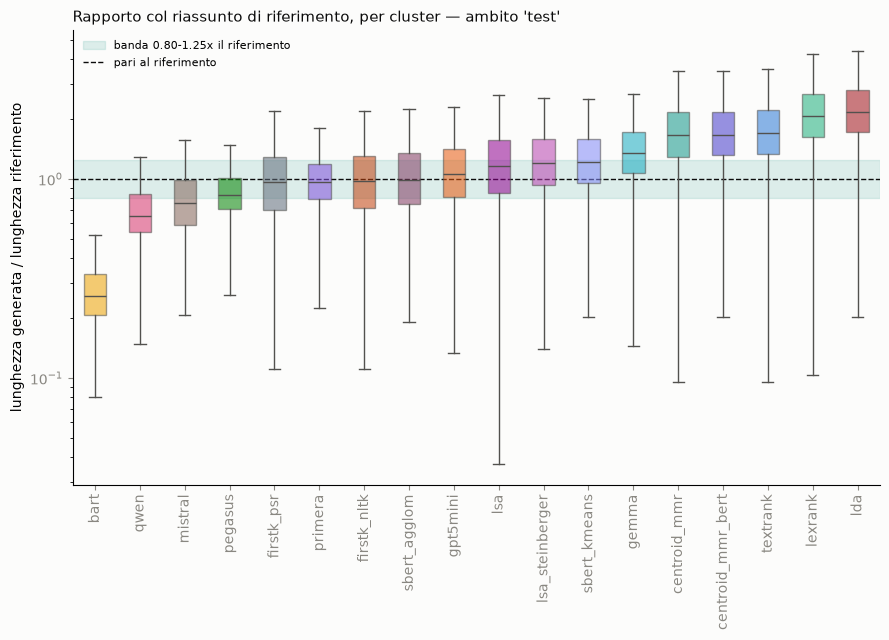

In [7]:
righe_tabella = {}
for m in metodi:
    d = per_metodo[m]
    r = d['rapporto_riferimento']
    righe_tabella[m] = {
        'parole (media)': d['parole']['media'],
        'p10': r['p10'], 'mediana': r['p50'], 'p90': r['p90'],
        'in banda %': d['pct_in_banda'],
        'corr(riferimento)': d['corr_len_riferimento'],
        'corr(n_articoli)': d['corr_len_n_articoli'],
    }
tabella_metodi = pd.DataFrame(righe_tabella).T.sort_values('mediana')
display(tabella_metodi)

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ordinati = list(tabella_metodi.index)
serie = [np.array([lunghezze[m][r] for r in comuni], dtype=np.float64) / np.maximum(R, 1)
        for m in ordinati]
ax.axhspan(BANDA[0], BANDA[1], color='#2a9d8f', alpha=0.15,
          label=f'banda {BANDA[0]:.2f}-{BANDA[1]:.2f}x il riferimento', zorder=1)
ax.axhline(1.0, color=INK, lw=1, ls='--', label='pari al riferimento', zorder=1)
bp = ax.boxplot(serie, showfliers=False, tick_labels=ordinati, patch_artist=True, zorder=2)
for patch, m in zip(bp['boxes'], ordinati):
    patch.set_facecolor(COLORI.get(m, MUTED))
    patch.set_alpha(0.55)
    patch.set_edgecolor(INK2)
for elem in ('whiskers', 'caps', 'medians'):
    for line in bp[elem]:
        line.set_color(INK2)
ax.set_yscale('log')
ax.set_ylabel('lunghezza generata / lunghezza riferimento')
ax.set_title(f"Rapporto col riassunto di riferimento, per cluster — ambito '{SCOPE}'",
            color=INK, loc='left', fontsize=11)
ax.tick_params(axis='x', rotation=90, colors=MUTED)
ax.tick_params(axis='y', colors=MUTED)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


## Vista 4 — Un metodo per famiglia: riferimento vs lunghezza generata

Un campione di metodi rappresentativo delle diverse famiglie (estrattivo a budget di frasi,
astrattivo specializzato, astrattivo compatto, LLM cloud): la diagonale è dove starebbe un metodo
che riproduce esattamente la lunghezza del riferimento.


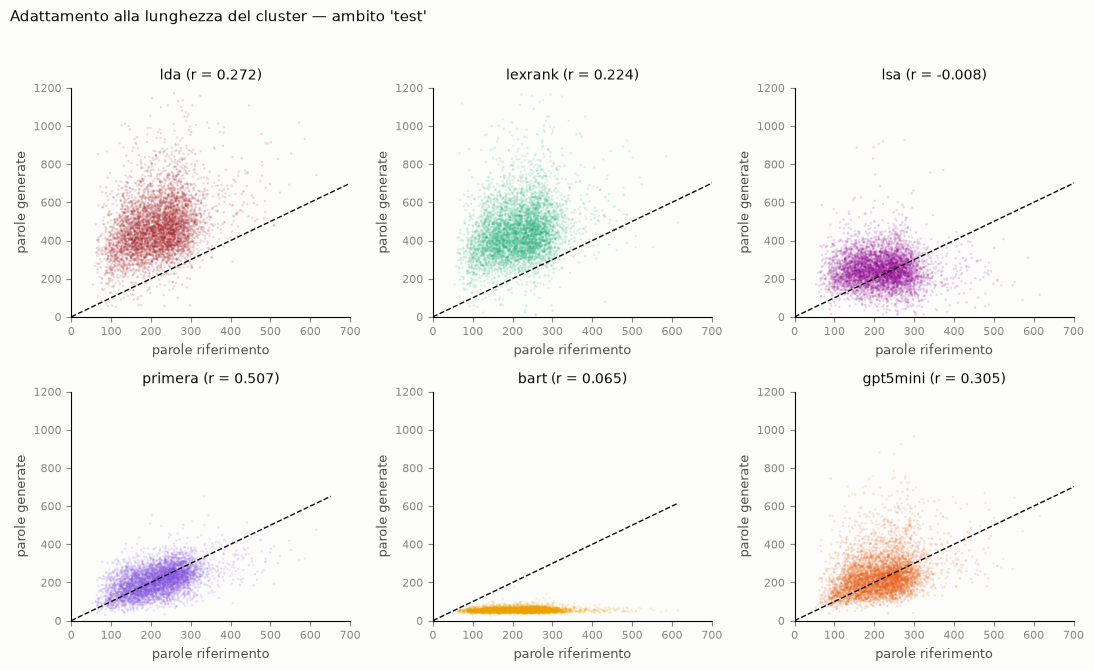

In [8]:
campione = [m for m in ('lda', 'lexrank', 'lsa', 'primera', 'bart', 'gpt5mini') if m in lunghezze]
if campione:
    n_colonne = 3
    n_righe = (len(campione) + n_colonne - 1) // n_colonne
    fig, axes = plt.subplots(n_righe, n_colonne, figsize=(11, 3.4 * n_righe),
                             facecolor=SURFACE, squeeze=False)
    for ax, metodo in zip(axes.ravel(), campione):
        ax.set_facecolor(SURFACE)
        L = np.array([lunghezze[metodo][r] for r in comuni], dtype=np.float64)
        ax.scatter(R, L, s=3, alpha=0.15, color=COLORI.get(metodo, '#457b9d'), edgecolors='none')
        lim = float(max(R.max(), L.max()))
        ax.plot([0, lim], [0, lim], color=INK, lw=1, ls='--')
        r = per_metodo[metodo]['corr_len_riferimento']
        ax.set_title(f'{metodo} (r = {r})', color=INK, fontsize=10)
        ax.set_xlabel('parole riferimento', color=INK2, fontsize=9)
        ax.set_ylabel('parole generate', color=INK2, fontsize=9)
        ax.set_xlim(0, 700)
        ax.set_ylim(0, 1200)
        ax.tick_params(colors=MUTED, labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    for ax in axes.ravel()[len(campione):]:
        ax.axis('off')
    fig.suptitle(f"Adattamento alla lunghezza del cluster — ambito '{SCOPE}'", color=INK,
                x=0.01, ha='left', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Vista 5 — Quale budget per cluster? Confronto dei predittori

Il contenimento ha bisogno di un budget di parole per ogni cluster. La Vista 2 suggerisce
`T(n_articoli)`; ma quanto *aiuta davvero* conoscere il numero di articoli — o la lunghezza
della sorgente, o entrambi — a prevedere la lunghezza del riferimento di un singolo cluster?

Qui ogni candidato viene **tarato sulla split train** e valutato **sulla split test**: errore
assoluto medio in parole, errore percentuale mediano, quota di cluster il cui riferimento cade
nella banda `[0,80, 1,25] × budget`, e correlazione di rango fra budget e riferimento (quanto il
budget *ordina* bene i cluster). Due estremi fanno da riferimento: un budget **costante** (la
mediana di train, nessuna informazione dal cluster) e l'**oracolo** (il riferimento stesso, il
massimo raggiungibile).


In [9]:
def colonne(righe_split):
    a = np.array([(n, rif, src) for _, n, rif, src in righe_split], dtype=np.float64)
    return a[:, 0], a[:, 1], a[:, 2]          # n_articoli, parole_riferimento, parole_sorgente

na_tr, tw_tr, sw_tr = colonne(righe['train'])
na_te, tw_te, sw_te = colonne(righe[SPLIT_RIFERIMENTI])
ok_tr = (sw_tr > 0) & (tw_tr > 0)


def mediana_per_gruppo(chiavi_tr, y_tr, chiavi):
    """Mediana di y per gruppo, tarata su train e applicata alle chiavi richieste."""
    tab = {k: float(np.median(y_tr[chiavi_tr == k])) for k in np.unique(chiavi_tr)}
    default = float(np.median(list(tab.values())))
    return np.array([tab.get(k, default) for k in chiavi])


def bin_quantili(x_tr, x, n_bin):
    edges = np.quantile(x_tr, np.linspace(0, 1, n_bin + 1)[1:-1])
    return np.searchsorted(edges, x)


def spearman(x, y):
    rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx, ry)[0, 1])


candidati = {}
# A. costante: la mediana di train, nessuna informazione dal cluster
candidati['A  costante (mediana train)'] = np.full_like(tw_te, np.median(tw_tr))
# B. mediana per numero di articoli — la T(n_articoli) della Vista 2
b_tr, b_te = np.minimum(na_tr, BUCKET_MASSIMO), np.minimum(na_te, BUCKET_MASSIMO)
candidati['B  mediana per n_articoli (T)'] = mediana_per_gruppo(b_tr, tw_tr, b_te)
# C1. mediana per decile di lunghezza della sorgente
candidati['C1 mediana per 10 decili di parole sorgente'] = mediana_per_gruppo(
    bin_quantili(sw_tr, sw_tr, 10), tw_tr, bin_quantili(sw_tr, sw_te, 10))
# C2. regressione log-log riferimento ~ sorgente
b, a = np.polyfit(np.log(sw_tr[ok_tr]), np.log(tw_tr[ok_tr]), 1)
candidati[f'C2 log-log riferimento ~ sorgente (esp. {b:.2f})'] = np.exp(a + b * np.log(np.maximum(sw_te, 1)))
# C3. compressione costante: riferimento = sorgente / mediana(sorgente/riferimento)
c = float(np.median(sw_tr[ok_tr] / tw_tr[ok_tr]))
candidati[f'C3 sorgente / compressione mediana ({c:.1f})'] = sw_te / c
# D. mediana per (n_articoli, terzile di sorgente dentro il bucket)
edges = {k: np.quantile(sw_tr[b_tr == k], [1/3, 2/3]) for k in np.unique(b_tr)}
def chiave_D(bk, sw):
    return np.array([k * 10 + int(np.searchsorted(edges[k], s)) for k, s in zip(bk, sw)])
candidati['D  mediana per n_articoli x terzile sorgente'] = mediana_per_gruppo(
    chiave_D(b_tr, sw_tr), tw_tr, chiave_D(b_te, sw_te))
# E. regressione log-log con entrambi
X = np.column_stack([np.ones(ok_tr.sum()), np.log(sw_tr[ok_tr]), np.log(na_tr[ok_tr])])
coef, *_ = np.linalg.lstsq(X, np.log(tw_tr[ok_tr]), rcond=None)
Xte = np.column_stack([np.ones(len(sw_te)), np.log(np.maximum(sw_te, 1)), np.log(na_te)])
candidati[f'E  log-log riferimento ~ sorgente + n_articoli'] = np.exp(Xte @ coef)
# F. oracolo: il riferimento stesso (limite superiore, NON un budget utilizzabile in produzione)
candidati['F  oracolo = lunghezza del riferimento'] = tw_te.copy()

righe_confronto = {}
for nome, pred in candidati.items():
    pred = np.maximum(pred, 1)
    righe_confronto[nome] = {
        'MAE (parole)': round(float(np.mean(np.abs(pred - tw_te))), 1),
        'APE mediano %': round(float(np.median(np.abs(pred - tw_te) / np.maximum(tw_te, 1)) * 100), 1),
        'riferimento in banda %': round(float(np.mean((tw_te >= BANDA[0] * pred)
                                                       & (tw_te <= BANDA[1] * pred)) * 100), 1),
        'spearman': round(spearman(pred, tw_te), 3) if np.std(pred) > 0 else None,
    }
confronto_budget = pd.DataFrame(righe_confronto).T
display(confronto_budget)


,MAE (parole),APE mediano %,riferimento in banda %,spearman
A costante (mediana train),53.2,20.0,54.2,NaN
B mediana per n_articoli (T),48.1,19.0,56.7,0.362
C1 mediana per 10 decili di parole sorgente,48.0,18.4,57.7,0.402
C2 log-log riferimento ~ sorgente (esp. 0.18),48.6,19.4,55.2,0.407
C3 sorgente / compressione mediana (6.4),137.7,41.3,27.6,0.407
D mediana per n_articoli x terzile sorgente,46.5,18.4,58.0,0.436
E log-log riferimento ~ sorgente + n_articoli,46.7,18.8,56.7,0.457
F oracolo = lunghezza del riferimento,0.0,0.0,100.0,1.000


### Che cosa dice il confronto

1. **Niente di calcolabile dal solo input prevede bene la lunghezza del riferimento.** Il miglior
   candidato non-oracolo (D, numero di articoli × terzile di sorgente) mette il riferimento in
   banda nel ~58% dei cluster; un budget **costante** lo fa nel ~54%. Tutta la macchina
   per-cluster — tabelle, bucket, regressioni — compra 2–4 punti percentuali, e la correlazione
   di rango non supera 0,46. La lunghezza del riferimento è in larga parte una scelta
   idiosincratica di chi lo ha scritto, non una funzione del cluster.
2. **`T(n_articoli)` era una motivazione sopravvalutata.** Che le *mediane* per bucket vadano da
   ~164 a ~327 parole è vero, ma la dispersione dentro ogni bucket è tale che conoscere il bucket
   aiuta poco per il singolo cluster (Spearman 0,36). E l'81% dei cluster di test ha 2–3
   articoli, dove `T` vale 194–232 ≈ la costante: la tabella «fa qualcosa» solo nella coda.
3. **L'idea intuitiva «scala con la lunghezza della sorgente» (C3) è proprio sbagliata**: MAE
   ~138 parole, perché il rapporto di compressione varia di 5× fra cluster (p25 4,0 → p75 9,8).

**Conseguenza per il contenimento.** Lo scopo del budget è dare a ogni metodo *lo stesso*
bersaglio per cluster, così che il confronto non dipenda dalla lunghezza; quanto quel bersaglio
somigli al riferimento conta solo per la fedeltà dei numeri assoluti. Su questo il confronto è
netto: fra i budget non-oracolo il costante è già quasi ottimo, e il candidato che davvero
elimina la lunghezza come confondente è l'**oracolo (F)** — il riferimento stesso, cluster per
cluster. Con `|candidato| ≈ |riferimento|` il richiamo ROUGE e la precisione coincidono e
l'obiezione «i riassunti lunghi vincono sul recall» non può più nascere per costruzione. È il
protocollo *length-matched* / *oracle-length* della letteratura (es. Sun et al., 2019): usa
un'informazione gold — la sola **lunghezza**, mai il contenuto — e va dichiarato come tale,
perché risponde a «quanto è buona la selezione dei contenuti a parità di lunghezza», non a «cosa
otterrebbe il metodo in produzione». La scelta e la sua applicazione ai 18 metodi sono
documentate in una issue dedicata, richiamata dalla #15.


## Salvataggio

L'analisi va in `results/metrics/analisi_lunghezze_{ambito}.json` (committato), lo stesso
pattern di `scripts/dataset_stats.json` per l'EDA del corpus: un unico oggetto JSON che altri
possono leggere senza rieseguire questo notebook.


In [10]:
risultato = {
    'scope': SCOPE, 'split': SPLIT_RIFERIMENTI, 'banda': list(BANDA),
    'n_cluster': len(comuni), 'metodi': metodi,
    'riferimento': distribuzione(R, 1),
    'n_articoli': distribuzione(A, 2),
    'dispersione_per_cluster': dispersione,
    'per_metodo': per_metodo,
    'tabella_budget': T, 'split_taratura_budget': 'train',
    'confronto_budget': {nome: v for nome, v in righe_confronto.items()},
}
out = P['metrics_dir'] / f'analisi_lunghezze_{SCOPE}.json'
out.write_text(json.dumps(risultato, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Analisi salvata: {out}')


Analisi salvata: C:\Users\antonio.girasella\source\repos\multi-news-ai4stem-polito-master\results\metrics\analisi_lunghezze_test.json
